Netflix Data Analysis Project


Importing Libraries 

In [47]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Reading the CSV File

In [48]:
df = pd.read_csv("netflix_titles.csv.zip")
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


Exploring the CSV File

In [49]:
df.shape
df.info()
df.isnull().sum()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      6173 non-null   str  
 4   cast          7982 non-null   str  
 5   country       7976 non-null   str  
 6   date_added    8797 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8803 non-null   str  
 9   duration      8804 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 825.8 KB


,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


Deleting Duplicates

In [50]:
df.drop_duplicates(inplace=True)


Filling Missing Positions

In [51]:
df['director'].fillna('Unknown', inplace=True)
df['country'].fillna('Unknown', inplace=True)

/var/folders/8h/8px1pn9d395_820kynwzdqg40000gn/T/ipykernel_42037/102835852.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['director'].fillna('Unknown', inplace=True)
/var/folders/8h/8px1pn9d395_820kynwzdqg40000gn/T/ipykernel_42037/102835852.py:2: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series 

0       United States
1        South Africa
2             Unknown
3             Unknown
4               India
            ...      
8802    United States
8803          Unknown
8804    United States
8805    United States
8806            India
Name: country, Length: 8807, dtype: str

In [52]:
df['type'].value_counts()

type
Movie      6131
TV Show    2676
Name: count, dtype: int64

Movies vs TV Shows

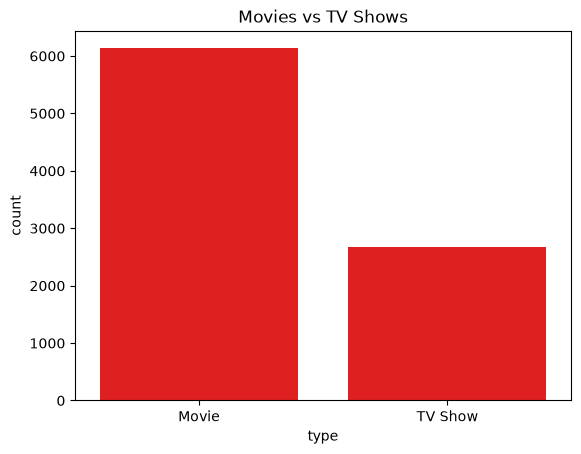

In [53]:
sns.countplot(x='type', data=df, color='red')
plt.title("Movies vs TV Shows")
plt.show()

Top 10 Countries Using Netflix

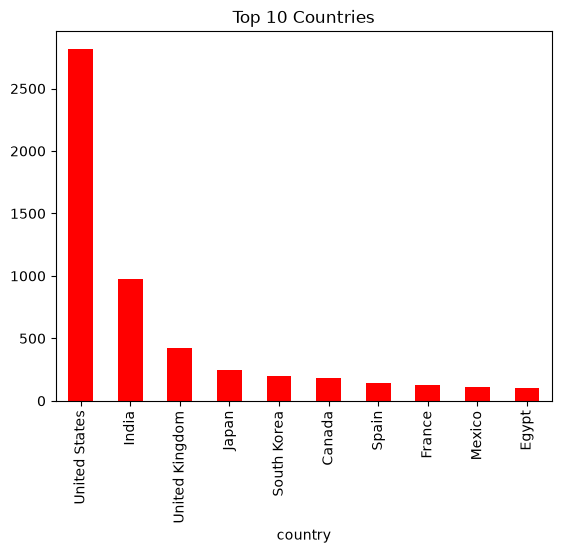

In [54]:
df['country'].value_counts().head(10)
df['country'].value_counts().head(10).plot(kind='bar', color='Red')
plt.title("Top 10 Countries")
plt.show()

Content Released Each Year

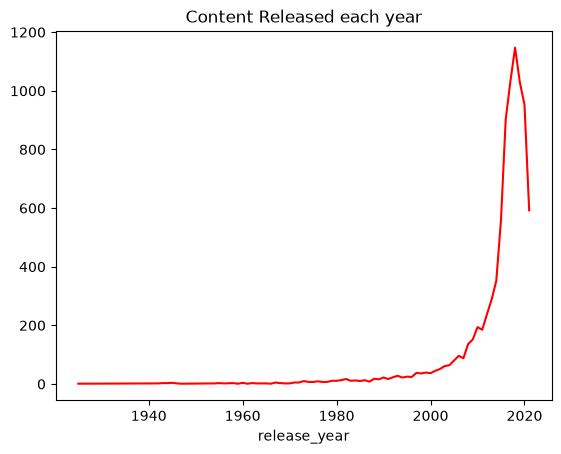

In [55]:
df['release_year'].value_counts().sort_index()
df['release_year'].value_counts().sort_index().plot(color='Red')
plt.title("Content Released each year")
plt.show()

Distribution of Content Ratings

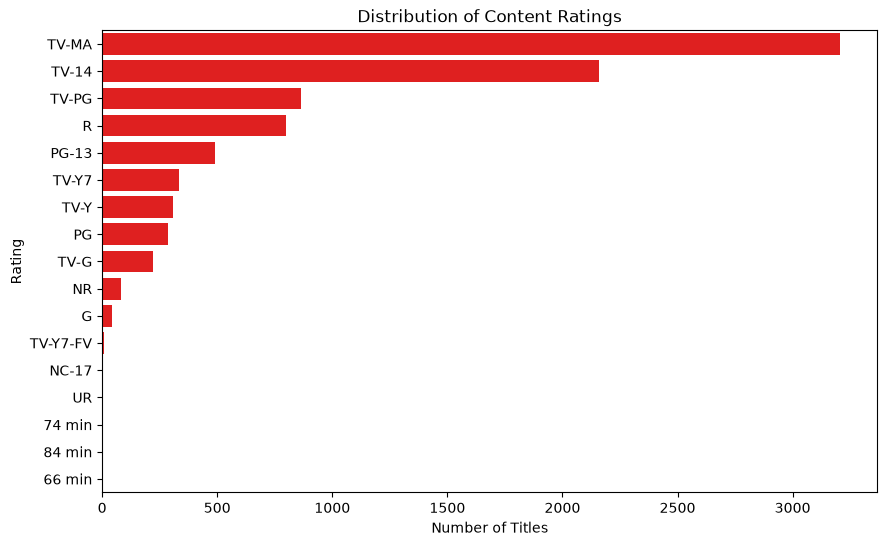

In [56]:
df['rating'].value_counts()
plt.figure(figsize=(10,6))

sns.countplot(
    data=df,
    y='rating',
    order=df['rating'].value_counts().index,
    color='Red'
   
)

plt.title("Distribution of Content Ratings")
plt.xlabel("Number of Titles")
plt.ylabel("Rating")

plt.show()

Top 10 Genres on Netflix

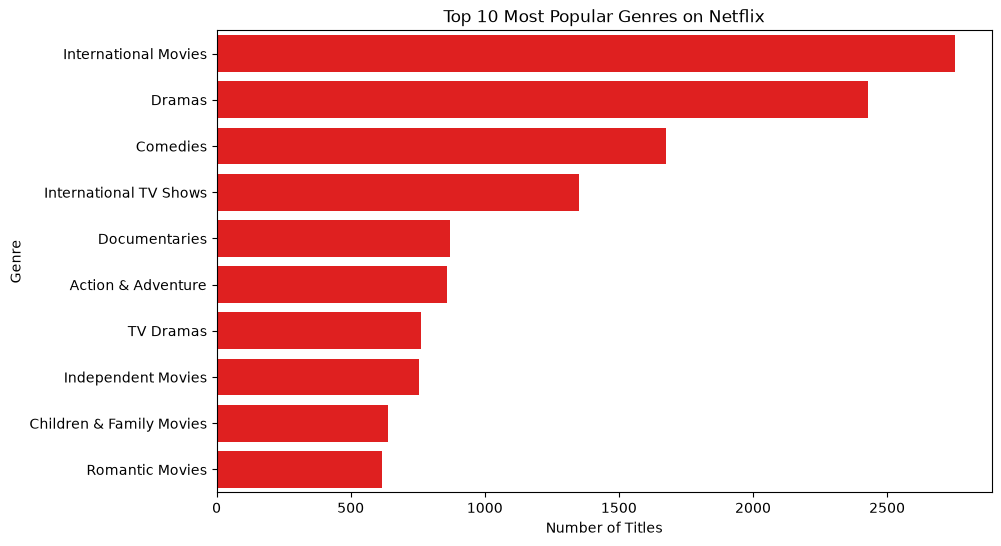

In [57]:
df['listed_in'].value_counts().head(10)
genre = df.copy()

genre['listed_in'] = genre['listed_in'].str.split(',')

genre = genre.explode('listed_in')

genre['listed_in'] = genre['listed_in'].str.strip()

top_genres = genre['listed_in'].value_counts().head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    x=top_genres.values,
    y=top_genres.index,
    color='Red'
)

plt.title("Top 10 Most Popular Genres on Netflix")
plt.xlabel("Number of Titles")
plt.ylabel("Genre")

plt.show()

Distribution of Movie Durations on Netflix

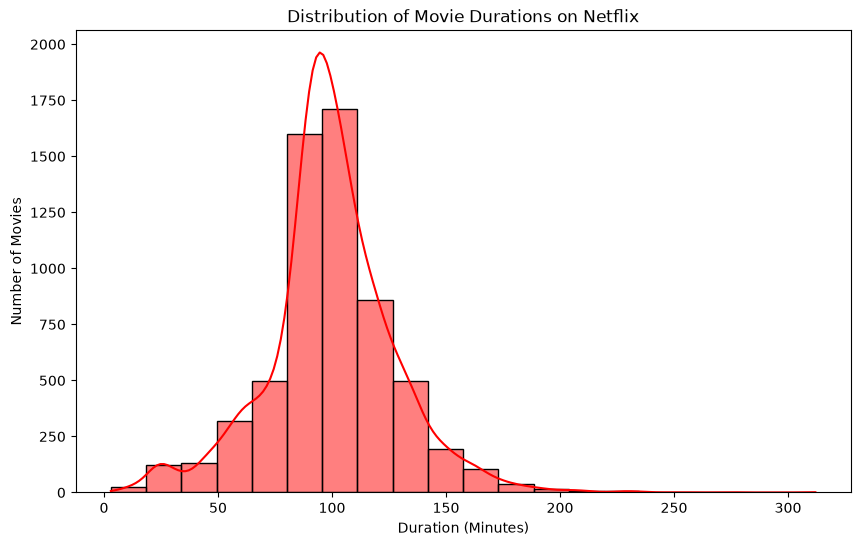

In [58]:

movies = df[df['type'] == 'Movie'].copy()

# Remove rows with missing duration
movies = movies.dropna(subset=['duration'])


movies['duration'] = movies['duration'].str.replace(' min', '', regex=False)


movies['duration'] = movies['duration'].astype(int)

plt.figure(figsize=(10,6))

sns.histplot(
    data=movies,
    x='duration',
    bins=20,
    kde=True,
    color='Red'
)

plt.title("Distribution of Movie Durations on Netflix")
plt.xlabel("Duration (Minutes)")
plt.ylabel("Number of Movies")

plt.show()